In [14]:
import neurokit2 as nk
import pandas as pd
import numpy as np

## EKG

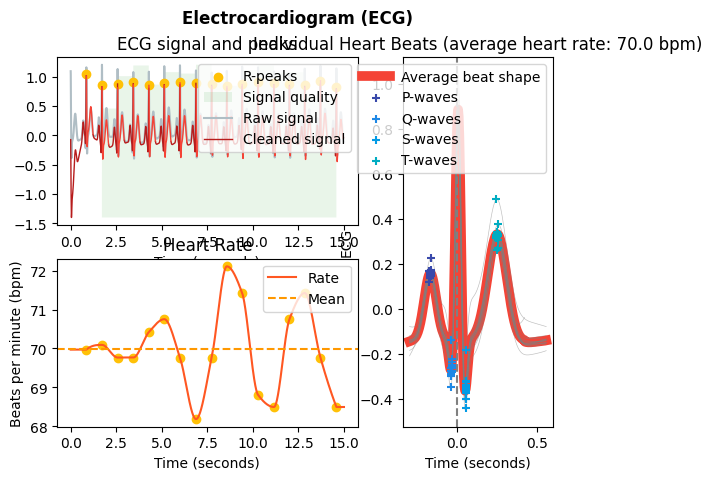

In [7]:
# Generate 15 seconds of ECG signal (recorded at 250 samples/second)
ecg = nk.ecg_simulate(duration=15, sampling_rate=250, heart_rate=70)

# Process it
signals, info = nk.ecg_process(ecg, sampling_rate=250)

# Visualise the processing
nk.ecg_plot(signals, info)

In [31]:
import pandas as pd
import numpy as np

df = pd.read_excel("validation_data/BrainFlow-RAW_2026-04-02_01-40-52_0.xlsx")

# Extract column 2 (index 1), starting from row 2 (index 1)
ppg_col = df.iloc[1:, 1]

# Option 1: pandas Series
ppg_signal_series = ppg_col.dropna()

# Option 2: NumPy array
ppg_signal_np = ppg_col.dropna().to_numpy()

# Option 3: Python list
ppg_signal_list = ppg_col.dropna().tolist()


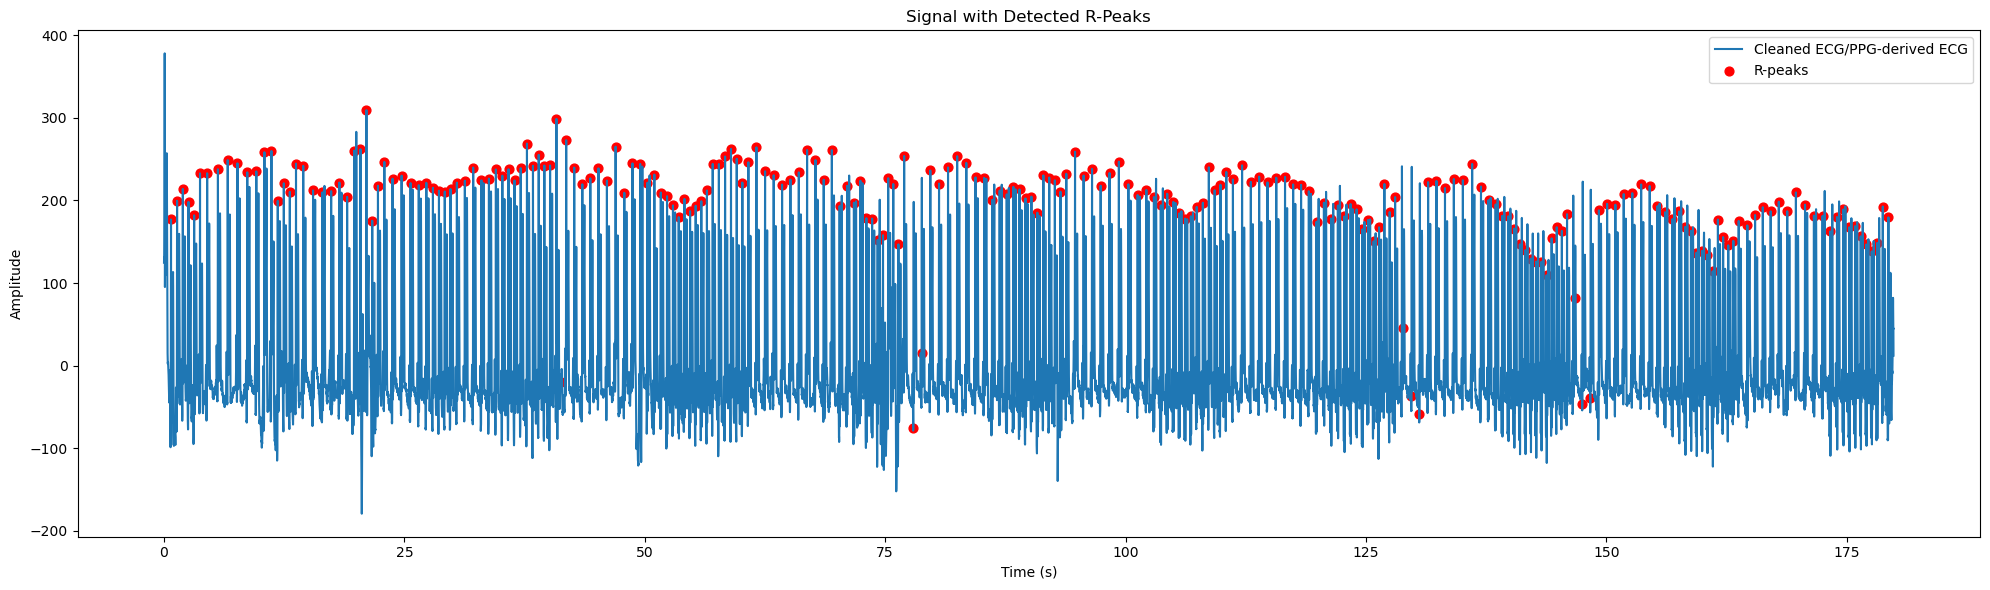

In [32]:
# Process it
signals, info = nk.ecg_process(ppg_signal_list, sampling_rate=250)

# Visualise the processing
# nk.ecg_plot(signals, info)

import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np

# signals, info = nk.ecg_process(ppg_signal_list, sampling_rate=250)

# Extract the processed ECG signal and R-peaks
ecg_clean = signals["ECG_Clean"]
rpeaks = info["ECG_R_Peaks"]

# Create time axis in seconds
sampling_rate = 250
duration = len(ecg_clean) / sampling_rate
time = np.linspace(0, duration, len(ecg_clean))

# Plot
plt.figure(figsize=(20, 6))
plt.plot(time, ecg_clean, label="Cleaned ECG/PPG-derived ECG")

# Overlay R-peaks
plt.scatter(time[rpeaks], ecg_clean[rpeaks], color="red", s=40, label="R-peaks")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal with Detected R-Peaks")
plt.legend()
plt.tight_layout()
plt.show()


In [33]:

import plotly.graph_objects as go
from IPython.display import HTML

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=time,
    y=ecg_clean,
    mode='lines',
    name='Cleaned ECG/PPG-derived ECG',
    line=dict(color='steelblue', width=1)
))

fig.add_trace(go.Scatter(
    x=time[rpeaks],
    y=ecg_clean[rpeaks],
    mode='markers',
    marker=dict(color='red', size=6, symbol='circle'),
    name='R-peaks'
))

fig.update_layout(
    title='Signal with Detected R-Peaks (Interactive)',
    xaxis_title='Time (s)',
    yaxis_title='Amplitude',
    width=1200,
    height=500,
    hovermode='x unified'
)

HTML(fig.to_html(include_plotlyjs='cdn'))


## Validating ECG vs PPG

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("BrainFlow-RAW_2025-11-25_export_data_0.xlsx")

# Extract column 2 (index 1), starting from row 2 (index 1)
ppg_col = df.iloc[1:, 1]

# Option 1: pandas Series
ppg_signal_series = ppg_col.dropna()

# Option 2: NumPy array
ppg_signal_np = ppg_col.dropna().to_numpy()

# Option 3: Python list
ppg_signal_list = ppg_col.dropna().tolist()

# Process it
signals, info = nk.ecg_process(ppg_signal_list, sampling_rate=250)

# Visualise the processing
# nk.ecg_plot(signals, info)

import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np

# signals, info = nk.ecg_process(ppg_signal_list, sampling_rate=250)


# Extract the processed ECG signal and R-peaks
ecg_clean = signals["ECG_Clean"]
rpeaks = info["ECG_R_Peaks"]

# hrv stuff
hrv_info = nk.hrv_time(rpeaks, sampling_rate=250)
rmssd = hrv_info["HRV_RMSSD"]
print(f"RMSSD: {rmssd:.2f} ms")

# Create time axis in seconds
sampling_rate = 250
duration = len(ecg_clean) / sampling_rate
time = np.linspace(0, duration, len(ecg_clean))

# Plot
plt.figure(figsize=(20, 6))
plt.plot(time, ecg_clean, label="Cleaned ECG/PPG-derived ECG")

# Overlay R-peaks
plt.scatter(time[rpeaks], ecg_clean[rpeaks], color="red", s=40, label="R-peaks")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal with Detected R-Peaks")
plt.legend()
plt.tight_layout()
plt.show()


## PPG part of ecg vs ppg

## PPG

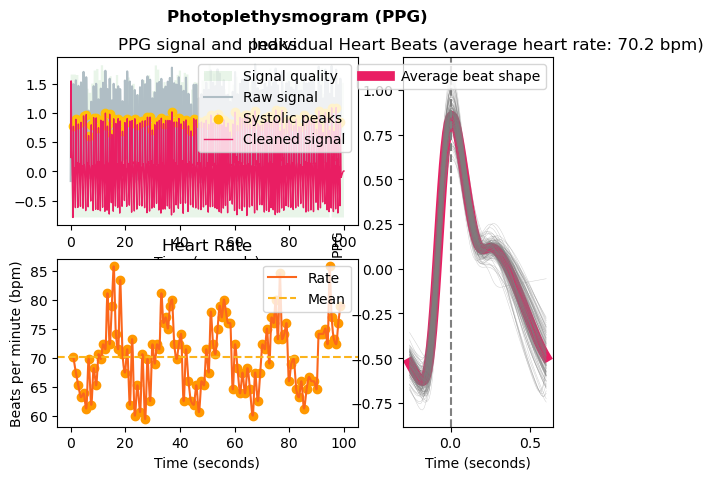

In [6]:
# Generate 15 seconds of PPG signal (recorded at 250 samples/second)
ppg = nk.ppg_simulate(duration=100, sampling_rate=100, heart_rate=70)

# Process it
signals, info = nk.ppg_process(ppg, sampling_rate=100)

# Visualize the processing
nk.ppg_plot(signals, info)

In [7]:
import heartpy as hp

# dataheartpy = hp.load_exampledata(0)
# fs = 100.0 #example file 0 is sampled at 100.0 Hz

working_data, measures = hp.process(ppg, fs, report_time=True)

print(measures['bpm']) #returns BPM value
print(measures['rmssd']) # returns RMSSD HRV measure


Finished in 0.023127 sec
70.04365039082327
73.48469228349535


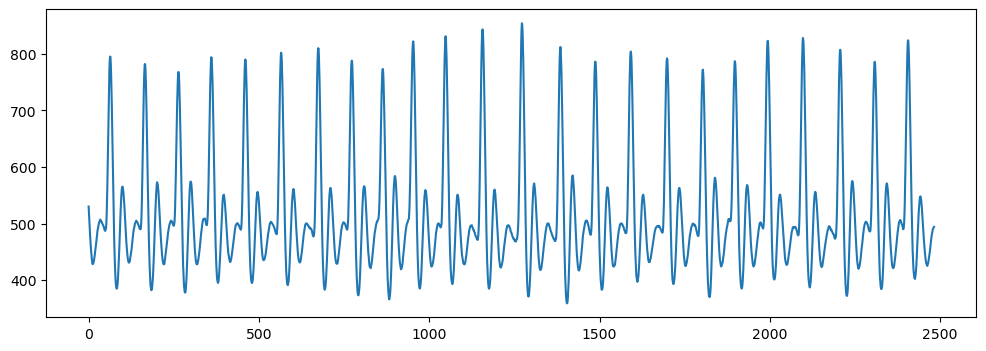

In [8]:
#First let's import
import heartpy as hp
import matplotlib.pyplot as plt

#first let's load the clean PPG signal
data, timer = hp.load_exampledata(0)

#and visualise
plt.figure(figsize=(12,4))
plt.plot(data)
plt.show()

bpm: 58.898848
ibi: 1018.695652
sdnn: 65.760061
sdsd: 34.866925
rmssd: 64.737231
pnn20: 0.863636
pnn50: 0.409091
hr_mad: 40.000000
sd1: 45.758077
sd2: 82.926832
s: 11921.000816
sd1/sd2: 0.551789
breathingrate: 0.170721


c:\Users\gur15\miniconda3\envs\capstone\lib\site-packages\heartpy\visualizeutils.py:119: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 1200x400 with 0 Axes>

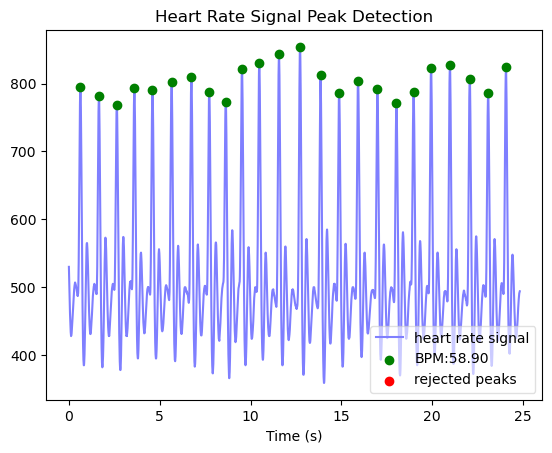

In [9]:
wd, m = hp.process(data, sample_rate = 100.0)
#set large figure
plt.figure(figsize=(12,4))

#call plotter
hp.plotter(wd, m)

#display measures computed
for measure in m.keys():
    print('%s: %f' %(measure, m[measure]))

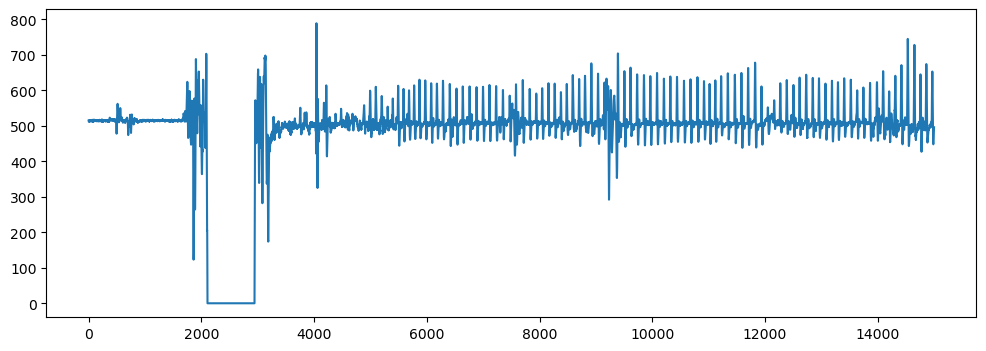

bpm: 62.376304
ibi: 961.903744
sdnn: 64.613519
sdsd: 29.871930
rmssd: 57.069746
pnn20: 0.797297
pnn50: 0.486486
hr_mad: 47.010333
sd1: 40.344402
sd2: 81.621935
s: 10345.227446
sd1/sd2: 0.494284
breathingrate: 0.266667


<Figure size 1200x400 with 0 Axes>

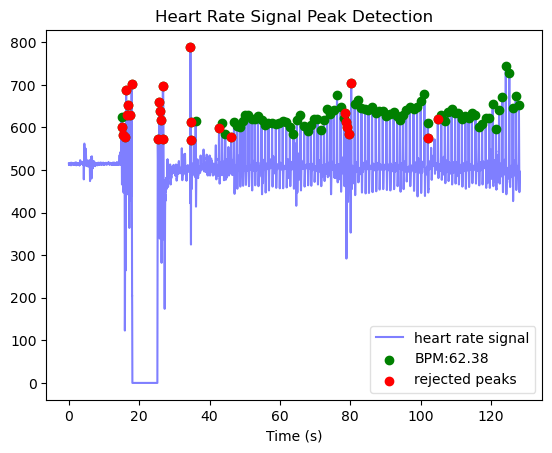

In [10]:
data, timer = hp.load_exampledata(1)

plt.figure(figsize=(12,4))
plt.plot(data)
plt.show()

sample_rate = hp.get_samplerate_mstimer(timer)

wd, m = hp.process(data, sample_rate)

#plot
plt.figure(figsize=(12,4))
hp.plotter(wd, m)

#display measures computed
for measure in m.keys():
    print('%s: %f' %(measure, m[measure]))

In [2]:
FS = 100  # Hz
DATA_PATH = "../ppg_dataset/semi_normal_run.txt"

def load_ppg(path):
    with open(path, "r") as f:
        data = [float(line.strip()) for line in f if line.strip()]
    return np.array(data, dtype=float)

forheartpy = load_ppg(DATA_PATH)

wd, m = hp.process(forheartpy, sample_rate = 100.0)
#set large figure
plt.figure(figsize=(12,4))

#call plotter
hp.plotter(wd, m)

#display measures computed
for measure in m.keys():
    print('%s: %f' %(measure, m[measure]))



NameError: name 'hp' is not defined

In [14]:
# Pretty-print helper to inspect the 'wd' and 'm' dictionaries
import pprint
import pandas as pd
from IPython.display import display, Markdown

def show_dict(name, d):
    display(Markdown(f'**{name} — keys:** {list(d.keys())}'))
    # If dict contains list/array-like values of similar length, show as DataFrame
    try:
        df = pd.DataFrame(d)
        # show a compact preview if large
        if df.size == 0:
            print('(empty DataFrame)')
        else:
            display(df.head(10))
    except Exception:
        print()
        pprint.pprint(d, width=120)

# Safety checks and display
if 'wd' in globals():
    show_dict('wd', wd)
else:
    print('Variable not found in this scope')

if 'm' in globals():
    # measures are usually flat; show as a single-row table for readability
    try:
        display(Markdown('**m — measures (as table)**'))
        display(pd.DataFrame([m]))
    except Exception:
        pprint.pprint(m, width=120)
else:
    print('Variable not found in this scope')

**wd — keys:** ['hr', 'sample_rate', 'peaklist', 'ybeat', 'rolling_mean', 'RR_list', 'RR_indices', 'RR_diff', 'RR_sqdiff', 'rrsd', 'best', 'removed_beats', 'removed_beats_y', 'binary_peaklist', 'RR_masklist', 'RR_list_cor', 'nn20', 'nn50', 'poincare', 'breathing_signal', 'breathing_psd', 'breathing_frq']


{'RR_diff': masked_array(data=[200.0, 0.0, 10.0, 30.0, 50.0, 40.0, 50.0, 50.0, 10.0,
                   10.0, 10.0, 20.0, 40.0, 40.0, 10.0, 20.0, 30.0, 30.0,
                   50.0, 40.0, 20.0, 80.0, 40.0, 40.0, 70.0, 70.0, 30.0,
                   0.0, 30.0, 10.0, 0.0, 30.0, 30.0, 20.0, 0.0, 80.0,
                   10.0, 30.0, 30.0, 10.0, 10.0, 50.0, 30.0, 30.0, 20.0,
                   0.0, 20.0, 20.0, 50.0, 60.0, 20.0, 10.0, 20.0, 20.0,
                   30.0, 70.0, 90.0, 20.0, 70.0, 50.0, 0.0, 10.0, 30.0,
                   20.0, 50.0, 0.0, 0.0, 10.0, 20.0, 20.0, 40.0, 20.0,
                   30.0, 0.0, 40.0, 10.0, 40.0, 10.0, 10.0, 40.0, 0.0,
                   40.0, 60.0, 20.0, 50.0, 30.0, 0.0, 40.0, 90.0, 50.0,
                   30.0, 40.0, 50.0, 50.0, 20.0, 20.0, 0.0, 10.0, 60.0,
                   100.0, 40.0, 70.0, 50.0, 20.0, 0.0, 40.0, 40.0, 20.0,
                   50.0, 120.0, 130.0, 20.0, 50.0, 60.0, 30.0, 70.0, 10.0,
                   60.0, 0.0, 10.0, 20.0, 20.0,

**m — measures (as table)**

**wd — keys:** ['hr', 'sample_rate', 'peaklist', 'ybeat', 'rolling_mean', 'RR_list', 'RR_indices', 'RR_diff', 'RR_sqdiff', 'rrsd', 'best', 'removed_beats', 'removed_beats_y', 'binary_peaklist', 'RR_masklist', 'RR_list_cor', 'nn20', 'nn50', 'poincare', 'breathing_signal', 'breathing_psd', 'breathing_frq']


{'RR_diff': masked_array(data=[200.0, 0.0, 10.0, 30.0, 50.0, 40.0, 50.0, 50.0, 10.0,
                   10.0, 10.0, 20.0, 40.0, 40.0, 10.0, 20.0, 30.0, 30.0,
                   50.0, 40.0, 20.0, 80.0, 40.0, 40.0, 70.0, 70.0, 30.0,
                   0.0, 30.0, 10.0, 0.0, 30.0, 30.0, 20.0, 0.0, 80.0,
                   10.0, 30.0, 30.0, 10.0, 10.0, 50.0, 30.0, 30.0, 20.0,
                   0.0, 20.0, 20.0, 50.0, 60.0, 20.0, 10.0, 20.0, 20.0,
                   30.0, 70.0, 90.0, 20.0, 70.0, 50.0, 0.0, 10.0, 30.0,
                   20.0, 50.0, 0.0, 0.0, 10.0, 20.0, 20.0, 40.0, 20.0,
                   30.0, 0.0, 40.0, 10.0, 40.0, 10.0, 10.0, 40.0, 0.0,
                   40.0, 60.0, 20.0, 50.0, 30.0, 0.0, 40.0, 90.0, 50.0,
                   30.0, 40.0, 50.0, 50.0, 20.0, 20.0, 0.0, 10.0, 60.0,
                   100.0, 40.0, 70.0, 50.0, 20.0, 0.0, 40.0, 40.0, 20.0,
                   50.0, 120.0, 130.0, 20.0, 50.0, 60.0, 30.0, 70.0, 10.0,
                   60.0, 0.0, 10.0, 20.0, 20.0,

**m — measures (as table)**

,bpm,ibi,sdnn,sdsd,rmssd,pnn20,pnn50,hr_mad,sd1,sd2,s,sd1/sd2,breathingrate
0,72.148953,831.612903,87.648986,29.977291,44.991781,0.532544,0.147929,60.0,31.585331,120.05697,11913.042281,0.263086,0.1


In [20]:
# Minimal: keep peaks from peaklist where binary_peaklist==1
accepted_peaklist = [p for p, b in zip(wd['peaklist'], wd['binary_peaklist']) if int(b) == 1]
print(accepted_peaklist)

[np.int64(26), np.int64(89), np.int64(172), np.int64(255), np.int64(337), np.int64(416), np.int64(490), np.int64(568), np.int64(651), np.int64(739), np.int64(826), np.int64(914), np.int64(1001), np.int64(1086), np.int64(1167), np.int64(1244), np.int64(1322), np.int64(1402), np.int64(1485), np.int64(1571), np.int64(1652), np.int64(1729), np.int64(1804), np.int64(1887), np.int64(1974), np.int64(2065), np.int64(2149), np.int64(2240), np.int64(2328), np.int64(2416), np.int64(2501), np.int64(2587), np.int64(2673), np.int64(2756), np.int64(2842), np.int64(2926), np.int64(3010), np.int64(3086), np.int64(3163), np.int64(3243), np.int64(3326), np.int64(3408), np.int64(3489), np.int64(3565), np.int64(3638), np.int64(3714), np.int64(3788), np.int64(3862), np.int64(3938), np.int64(4016), np.int64(4099), np.int64(4176), np.int64(4251), np.int64(4327), np.int64(4405), np.int64(4485), np.int64(4568), np.int64(4649), np.int64(4727), np.int64(4804), np.int64(4878), np.int64(4946), np.int64(5019), np.in

## Load Data

In [3]:
FS = 100  # Hz
DATA_PATH = "../ppg_dataset/movement_noise.txt"

def load_ppg(path):
    with open(path, "r") as f:
        data = [float(line.strip()) for line in f if line.strip()]
    return np.array(data, dtype=float)

loaded_run = load_ppg(DATA_PATH)

signals_run, info = nk.ppg_process(loaded_run, sampling_rate=FS)

## Class that does peak trough detection and amplitude calculation

In [4]:


import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import rfft, rfftfreq

class AdaptiveHRVBiofeedback:
    def __init__(self, fs=100):
        self.fs = fs
        
        # Wide HRV breathing band
        low = 0.04
        high = 0.4
        self.b, self.a = butter(
            2,
            [low/(fs/2), high/(fs/2)],
            btype='band'
        )
        
        self.last_peak_value = None
        self.amplitudes = []
        self.last_feedback_index = -1

    # -----------------------------
    # Estimate dominant breathing frequency
    # -----------------------------
    def estimate_breathing_freq(self, signal):
        n = len(signal)
        freqs = rfftfreq(n, 1/self.fs)
        fft_vals = np.abs(rfft(signal))
        
        # Limit to breathing band
        mask = (freqs >= 0.04) & (freqs <= 0.4)
        if np.sum(mask) == 0:
            return 0.1  # fallback
        
        dominant_freq = freqs[mask][np.argmax(fft_vals[mask])]
        
        if dominant_freq == 0:
            return 0.1
        
        return dominant_freq

    # -----------------------------
    # Main processing function
    # -----------------------------
    def process(self, hr_signal):
        if len(hr_signal) < self.fs * 10:
            return []  # need enough data
        
        # 1. Filter
        filtered = filtfilt(self.b, self.a, hr_signal)
        
        # 2. Estimate dominant breathing frequency
        dom_freq = self.estimate_breathing_freq(filtered)
        period = 1 / dom_freq
        
        # Physiological constraints
        period = np.clip(period, 3, 15)  # 4–20 bpm equivalent
        
        min_distance = int(self.fs * period * 0.5)
        
        # 3. Adaptive prominence (based on signal variability)
        prominence = np.std(filtered) * 0.5
        
        peaks, _ = find_peaks(
            filtered,
            distance=min_distance,
            prominence=prominence
        )
        
        troughs, _ = find_peaks(
            -filtered,
            distance=min_distance,
            prominence=prominence
        )
        
        events = sorted(
            [(i, 'peak') for i in peaks] +
            [(i, 'trough') for i in troughs]
        )
        
        feedback = []
        
        for idx, event_type in events:
            
            # Prevent duplicate feedback
            if idx <= self.last_feedback_index:
                continue
            
            value = filtered[idx]
            
            if event_type == 'peak':
                self.last_peak_value = value
            
            elif event_type == 'trough':
                if self.last_peak_value is not None:
                    amplitude = self.last_peak_value - value
                    
                    # Reject tiny/noise oscillations
                    if amplitude > 0.5:  # BPM threshold
                        self.amplitudes.append(amplitude)
                        
                        # Smooth last 3 breaths
                        smooth_amp = np.mean(self.amplitudes[-3:])
                        
                        feedback.append({
                            'index': idx,
                            'amplitude': smooth_amp,
                            'breathing_rate_bpm': dom_freq * 60
                        })
                        
                        self.last_feedback_index = idx
                    
                    self.last_peak_value = None
        
        return feedback

In [5]:
# Instantiate the class
biofeedback = AdaptiveHRVBiofeedback(fs=100)

# Use the class on signals['PPG_Rate']
feedback_results = biofeedback.process(signals_run['PPG_Rate'])

# Display feedback results
print(feedback_results)

[{'index': np.int64(615), 'amplitude': np.float64(18.756947579663965), 'breathing_rate_bpm': np.float64(10.200000000000001)}, {'index': np.int64(1257), 'amplitude': np.float64(19.214586456561534), 'breathing_rate_bpm': np.float64(10.200000000000001)}, {'index': np.int64(2416), 'amplitude': np.float64(21.422442118750883), 'breathing_rate_bpm': np.float64(10.200000000000001)}, {'index': np.int64(3095), 'amplitude': np.float64(22.74496862496113), 'breathing_rate_bpm': np.float64(10.200000000000001)}, {'index': np.int64(3608), 'amplitude': np.float64(29.22740165717869), 'breathing_rate_bpm': np.float64(10.200000000000001)}, {'index': np.int64(4463), 'amplitude': np.float64(45.10968167351812), 'breathing_rate_bpm': np.float64(10.200000000000001)}, {'index': np.int64(4844), 'amplitude': np.float64(61.62701493095437), 'breathing_rate_bpm': np.float64(10.200000000000001)}, {'index': np.int64(5170), 'amplitude': np.float64(64.61201444811428), 'breathing_rate_bpm': np.float64(10.200000000000001)

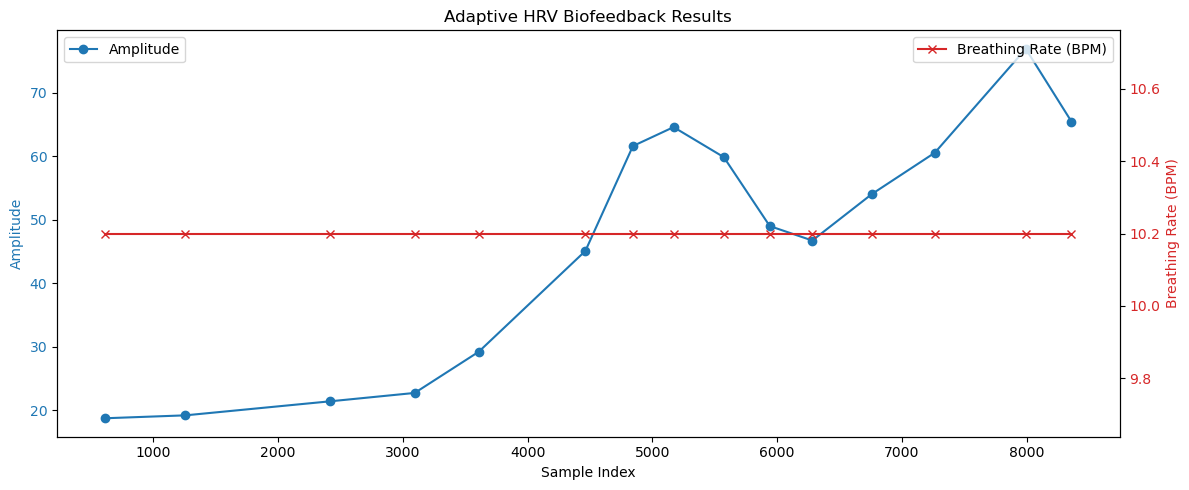

In [6]:
# Visualize feedback results from AdaptiveHRVBiofeedback
import matplotlib.pyplot as plt
import numpy as np

if feedback_results:
    indices = [item['index'] for item in feedback_results]
    amplitudes = [item['amplitude'] for item in feedback_results]
    breathing_rates = [item['breathing_rate_bpm'] for item in feedback_results]

    fig, ax1 = plt.subplots(figsize=(12, 5))

    color = 'tab:blue'
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Amplitude', color=color)
    ax1.plot(indices, amplitudes, color=color, marker='o', label='Amplitude')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Breathing Rate (BPM)', color=color)
    ax2.plot(indices, breathing_rates, color=color, marker='x', label='Breathing Rate (BPM)')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.legend(loc='upper right')

    plt.title('Adaptive HRV Biofeedback Results')
    plt.tight_layout()
    plt.show()
else:
    print('No feedback results to visualize.')

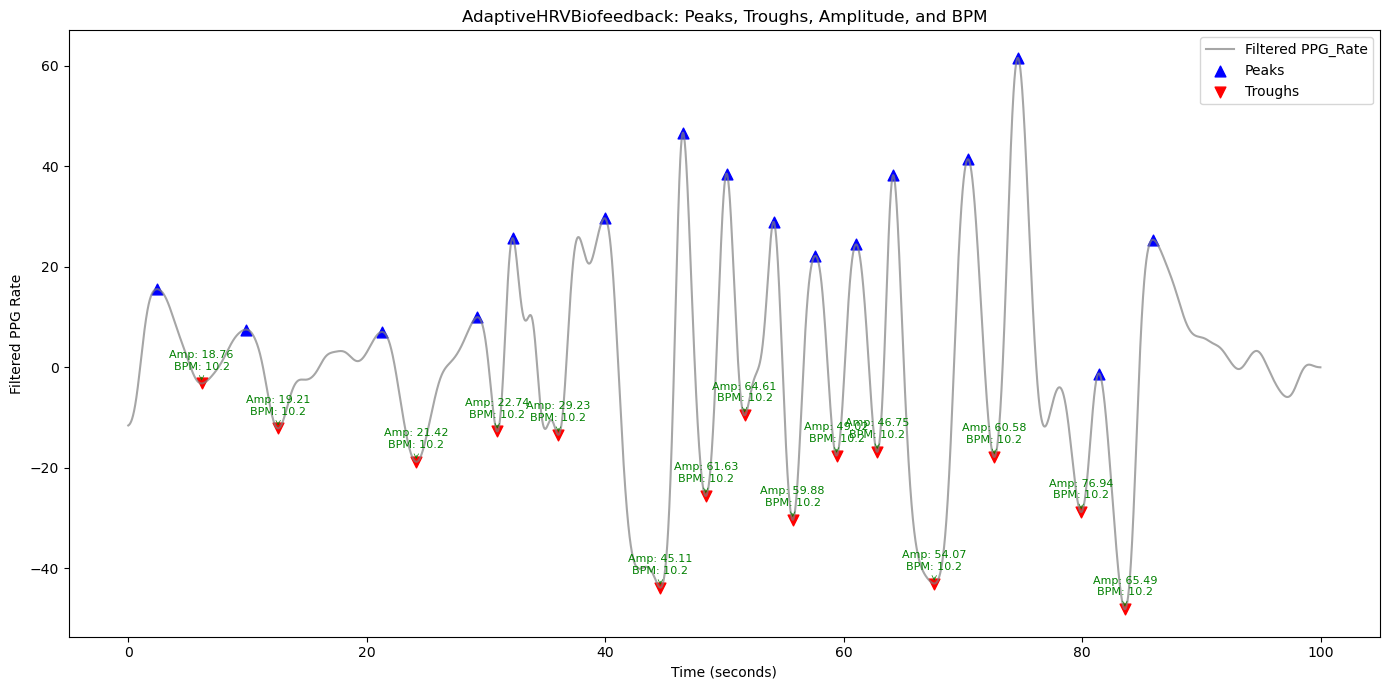

In [7]:
# Visualize peaks, troughs, amplitude, and BPM over time
import matplotlib.pyplot as plt
import numpy as np

# Get the original PPG_Rate signal and sampling frequency
ppg_rate = signals_run['PPG_Rate']
fs = 100  # Hz

time = np.arange(len(ppg_rate)) / fs  # seconds

# Re-run the process to extract peaks/troughs and feedback
biofeedback = AdaptiveHRVBiofeedback(fs=fs)
feedback_results = biofeedback.process(ppg_rate)

# For visualization, re-calculate filtered signal and find peaks/troughs
filtered = biofeedback.b, biofeedback.a
filtered_signal = np.array(ppg_rate)
if hasattr(biofeedback, 'b') and hasattr(biofeedback, 'a'):
    from scipy.signal import filtfilt
    filtered_signal = filtfilt(biofeedback.b, biofeedback.a, ppg_rate)

peaks, _ = biofeedback.process.__globals__['find_peaks'](filtered_signal, distance=int(fs * 0.5), prominence=np.std(filtered_signal) * 0.5)
troughs, _ = biofeedback.process.__globals__['find_peaks'](-filtered_signal, distance=int(fs * 0.5), prominence=np.std(filtered_signal) * 0.5)

plt.figure(figsize=(14, 7))
plt.plot(time, filtered_signal, label='Filtered PPG_Rate', color='gray', alpha=0.7)
plt.scatter(time[peaks], filtered_signal[peaks], color='blue', label='Peaks', s=60, marker='^')
plt.scatter(time[troughs], filtered_signal[troughs], color='red', label='Troughs', s=60, marker='v')

# Overlay amplitude and BPM from feedback_results
for item in feedback_results:
    idx = item['index']
    amp = item['amplitude']
    bpm = item['breathing_rate_bpm']
    plt.annotate(f"Amp: {amp:.2f}\nBPM: {bpm:.1f}", (time[idx], filtered_signal[idx]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='green',
                 arrowprops=dict(arrowstyle='->', color='green', lw=0.5))

plt.xlabel('Time (seconds)')
plt.ylabel('Filtered PPG Rate')
plt.title('AdaptiveHRVBiofeedback: Peaks, Troughs, Amplitude, and BPM')
plt.legend()
plt.tight_layout()
plt.show()

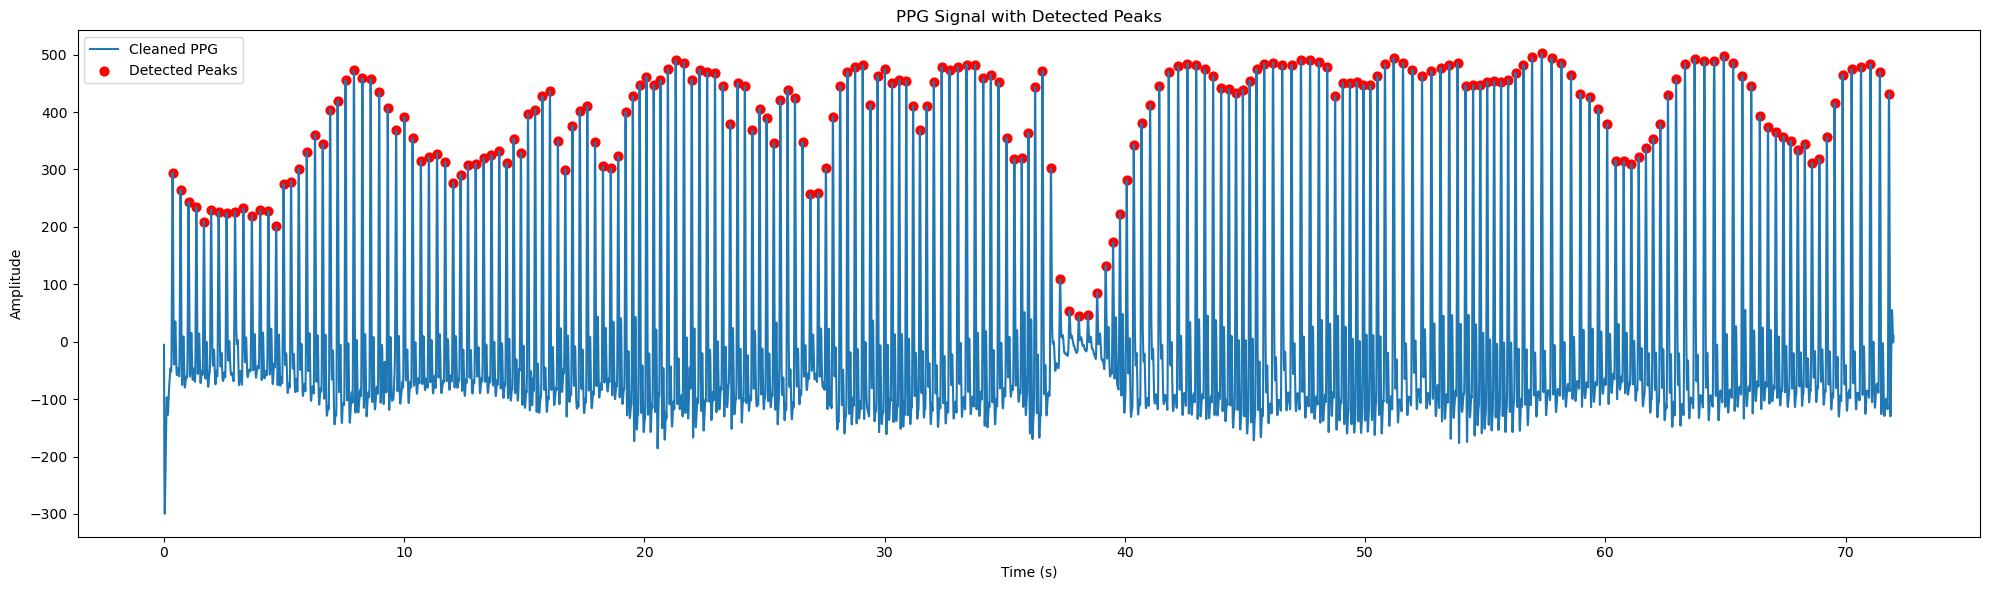

In [40]:
# Visualize PPG signal and detected peaks (PPG_Peaks)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 6))
plt.plot(signals.index / 250, signals['PPG_Clean'], label='Cleaned PPG')
plt.scatter(signals.index[signals['PPG_Peaks'] == 1] / 250, signals['PPG_Clean'][signals['PPG_Peaks'] == 1], color='red', s=40, label='Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('PPG Signal with Detected Peaks')
plt.legend()
plt.tight_layout()
plt.show()

       PPG_Raw   PPG_Clean   PPG_Rate  PPG_Quality  PPG_Peaks
0        522.0   35.219051  68.582955     0.975525          0
1        462.0   12.832431  68.582955     0.975525          0
2        443.0   -3.961402  68.582955     0.975525          0
3        448.0  -11.226305  68.582955     0.975525          0
4        468.0   -7.451137  68.582955     0.975525          0
...        ...         ...        ...          ...        ...
17946    540.0  103.356391  73.170732     0.997724          0
17947    528.0   96.288319  73.170732     0.997724          0
17948    518.0   90.577244  73.170732     0.997724          0
17949    509.0   85.839320  73.170732     0.997724          0
17950    498.0   81.656368  73.170732     0.997724          0

[17951 rows x 5 columns]
   PPG_Rate_Mean  HRV_MeanNN    HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  \
0      68.834679  874.852941  215.978648   45.302275   163.41896         NaN   

   HRV_SDNNI2  HRV_SDANN5  HRV_SDNNI5   HRV_RMSSD  ...  HRV_SampEn  \

c:\Users\gur15\miniconda3\envs\capstone\lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\gur15\miniconda3\envs\capstone\lib\site-packages\neurokit2\complexity\entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
c:\Users\gur15\miniconda3\envs\capstone\lib\site-packages\neurokit2\complexity\entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
c:\Users\gur15\miniconda3\envs\capstone\lib\site-packages\neurokit2\complexity\entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
c:\Users\gur15\miniconda3\envs\capston

   Time_sec       RMSSD
0    15.000   23.994949
1    45.000   24.436507
2    75.000   30.103986
3   105.000   44.123406
4   135.000   58.996993
5   164.755  771.736138


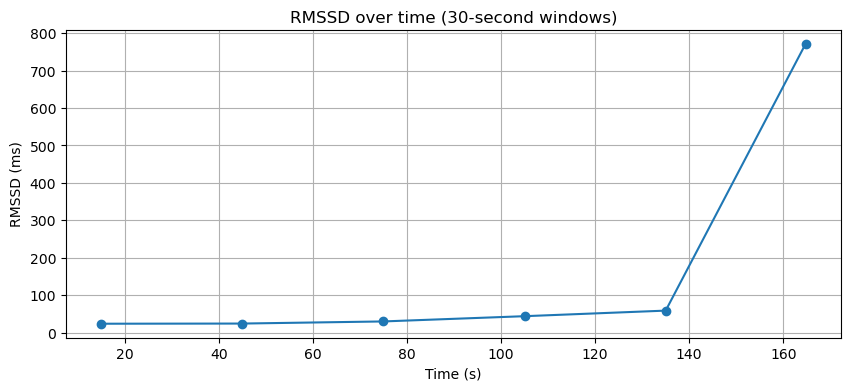

In [49]:
import pandas as pd

#df = pd.read_csv("parsed_data.csv")
#ppg = df["PPGSignal"].dropna().values

ppg = loaded_run

import neurokit2 as nk

signals, info = nk.ppg_process(ppg, sampling_rate=100)

print(signals)

hrvstuff = nk.ppg_intervalrelated(signals, sampling_rate=100)

print(hrvstuff)
# ibi = nk.ppg_interval(info)

# hrv = nk.hrv(ibi, sampling_rate=100, show=True)
# print(hrv)

import pandas as pd
import numpy as np

# Window size
window_size = 30 * 100  # 30 seconds at 60 Hz

# Number of windows
n_windows = int(np.ceil(len(signals) / window_size))

# Store RMSSD
rmssd_list = []
time_list = []

for i in range(n_windows):
    start = i * window_size
    end = min((i+1) * window_size, len(signals))
    window = signals.iloc[start:end]
    
    # Compute HRV for this window
    window_hrv = nk.ppg_intervalrelated(window, sampling_rate=100)
    
    # RMSSD is in 'HRV_RMSSD' column
    rmssd = window_hrv['HRV_RMSSD'].values[0]
    rmssd_list.append(rmssd)
    
    # Time point (middle of window, in seconds)
    mid_time = (start + end) / 2 / 100  # convert samples → seconds
    time_list.append(mid_time)

rmssd_df = pd.DataFrame({
    'Time_sec': time_list,
    'RMSSD': rmssd_list
})

print(rmssd_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(rmssd_df['Time_sec'], rmssd_df['RMSSD'], marker='o')
plt.xlabel('Time (s)')
plt.ylabel('RMSSD (ms)')
plt.title('RMSSD over time (30-second windows)')
plt.grid(True)
plt.show()



## HRV

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN
0,696.395349,62.135891,10.060728,60.275036,NaN,NaN,NaN,NaN,69.697983,69.779109,...,60.0,0.891502,660.0,740.0,14.651163,49.302326,470.0,1420.0,7.962963,234.375


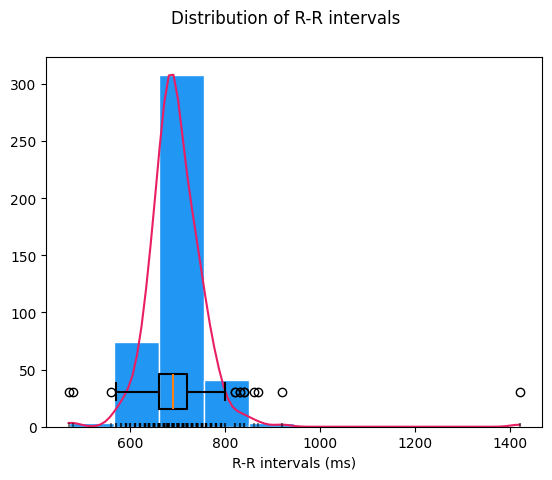

In [8]:
data = nk.data("bio_resting_5min_100hz")
data.head()  # Print first 5 rows

# Find peaks
peaks, info = nk.ecg_peaks(data["ECG"], sampling_rate=100)

# Extract clean EDA and SCR features
hrv_time = nk.hrv_time(peaks, sampling_rate=100, show=True)
hrv_time